# Assignment Two:  Sentiment Classification

For this exercise you will be using the "SemEval 2017 task 4" corpus provided on the module website, available through the following link: https://warwick.ac.uk/fac/sci/dcs/teaching/material/cs918/semeval-tweets.tar.bz2 You will focus particularly on Subtask A, i.e. classifying the overall sentiment of a tweet as positive, negative or neutral.

You are requested to produce a Jupyter notebook for the coursework submission. The input to your program is the SemEval data downloaded. Note that TAs need to run your program on their own machine by using the original SemEval data. As such, don’t submit a Python program that takes as input some preprocessed files.

#### Import necessary packages
You may import more packages here.

In [1]:
# Import necessary packages
import warnings
warnings.filterwarnings("ignore")
import re
from os.path import join
import numpy as np
import pandas as pd
import string
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import nltk
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
import os
import pickle
from sklearn.tree import DecisionTreeClassifier

# Download necessary NLTK resources
nltk.download('wordnet')  # For lemmatization
nltk.download('averaged_perceptron_tagger')  # For POS tagging
nltk.download('punkt')  # For tokenization
nltk.download('stopwords') #For stopwords




[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Define test sets
testsets = ['twitter-test1.txt', 'twitter-test2.txt', 'twitter-test3.txt']

In [3]:
# Skeleton: Evaluation code for the test sets
def read_test(testset):
    '''
    readin the testset and return a dictionary
    :param testset: str, the file name of the testset to compare
    '''
    id_gts = {}
    with open(testset, 'r', encoding='utf8') as fh:
        for line in fh:
            fields = line.split('\t')
            tweetid = fields[0]
            gt = fields[1]

            id_gts[tweetid] = gt

    return id_gts


def confusion(id_preds, testset, classifier):
    '''
    print the confusion matrix of {'positive', 'netative'} between preds and testset
    :param id_preds: a dictionary of predictions formated as {<tweetid>:<sentiment>, ... }
    :param testset: str, the file name of the testset to compare
    :classifier: str, the name of the classifier
    '''
    id_gts = read_test(testset)

    gts = []
    for m, c1 in id_gts.items():
        if c1 not in gts:
            gts.append(c1)

    gts = ['positive', 'negative', 'neutral']

    conf = {}
    for c1 in gts:
        conf[c1] = {}
        for c2 in gts:
            conf[c1][c2] = 0

    for tweetid, gt in id_gts.items():
        if tweetid in id_preds:
            pred = id_preds[tweetid]
        else:
            pred = 'neutral'
        conf[pred][gt] += 1

    print(''.ljust(12) + '  '.join(gts))

    for c1 in gts:
        print(c1.ljust(12), end='')
        for c2 in gts:
            if sum(conf[c1].values()) > 0:
                print('%.3f     ' % (conf[c1][c2] / float(sum(conf[c1].values()))), end='')
            else:
                print('0.000     ', end='')
        print('')

    print('')


def evaluate(id_preds, testset, classifier):
    '''
    print the macro-F1 score of {'positive', 'netative'} between preds and testset
    :param id_preds: a dictionary of predictions formated as {<tweetid>:<sentiment>, ... }
    :param testset: str, the file name of the testset to compare
    :classifier: str, the name of the classifier
    '''
    id_gts = read_test(testset)

    acc_by_class = {}
    for gt in ['positive', 'negative', 'neutral']:
        acc_by_class[gt] = {'tp': 0, 'fp': 0, 'tn': 0, 'fn': 0}

    catf1s = {}

    ok = 0
    for tweetid, gt in id_gts.items():
        if tweetid in id_preds:
            pred = id_preds[tweetid]
        else:
            pred = 'neutral'

        if gt == pred:
            ok += 1
            acc_by_class[gt]['tp'] += 1
        else:
            acc_by_class[gt]['fn'] += 1
            acc_by_class[pred]['fp'] += 1

    catcount = 0
    itemcount = 0
    macro = {'p': 0, 'r': 0, 'f1': 0}
    micro = {'p': 0, 'r': 0, 'f1': 0}
    semevalmacro = {'p': 0, 'r': 0, 'f1': 0}

    microtp = 0
    microfp = 0
    microtn = 0
    microfn = 0
    for cat, acc in acc_by_class.items():
        catcount += 1

        microtp += acc['tp']
        microfp += acc['fp']
        microtn += acc['tn']
        microfn += acc['fn']

        p = 0
        if (acc['tp'] + acc['fp']) > 0:
            p = float(acc['tp']) / (acc['tp'] + acc['fp'])

        r = 0
        if (acc['tp'] + acc['fn']) > 0:
            r = float(acc['tp']) / (acc['tp'] + acc['fn'])

        f1 = 0
        if (p + r) > 0:
            f1 = 2 * p * r / (p + r)

        catf1s[cat] = f1

        n = acc['tp'] + acc['fn']

        macro['p'] += p
        macro['r'] += r
        macro['f1'] += f1

        if cat in ['positive', 'negative']:
            semevalmacro['p'] += p
            semevalmacro['r'] += r
            semevalmacro['f1'] += f1

        itemcount += n

    micro['p'] = float(microtp) / float(microtp + microfp)
    micro['r'] = float(microtp) / float(microtp + microfn)
    micro['f1'] = 2 * float(micro['p']) * micro['r'] / float(micro['p'] + micro['r'])

    semevalmacrof1 = semevalmacro['f1'] / 2

    print(testset + ' (' + classifier + '): %.3f' % semevalmacrof1)

#### Load training set, dev set and testing set
Here, you need to load the training set, the development set and the test set. For better classification results, you may need to preprocess tweets before sending them to the classifiers.

In [4]:
import pandas as pd

# Variables for dataset filenames
train_data = 'twitter-training-data.txt'
dev_data = 'twitter-dev-data.txt'
testsets = ['twitter-test1.txt', 'twitter-test2.txt', 'twitter-test3.txt']
data_path = 'semeval-tweets'

# Initialize dictionaries to store data
data = {}
tweetids = {}
tweetgts = {}
tweets = {}

# Combine all datasets for processing
datasets = [train_data, dev_data] + testsets

# Load datasets and populate dictionaries
for dataset in datasets:
    dataset_path = f"{data_path}/{dataset}"
    df = pd.read_csv(dataset_path, sep='\t', header=None, names=['tweet_id', 'sentiment', 'tweet_text'])

    # Storing the whole dataframe in 'data'
    data[dataset] = df

    # Storing individual columns in separate dictionaries for easy access
    tweetids[dataset] = df['tweet_id'].tolist()
    tweetgts[dataset] = df['sentiment'].tolist()
    tweets[dataset] = df['tweet_text'].tolist()

# Example to show the first few rows of the loaded training data
print(data[train_data].head())
print(data[dev_data].head())

# Access each test set individually and print the first few rows
for testset in testsets:
    print(data[testset].head())


             tweet_id sentiment  \
0  335104872099066692  positive   
1  796528524030124618  positive   
2  760964834217238632  positive   
3  147713180324524046  negative   
4  732302280474120023  negative   

                                          tweet_text  
0  Felt privileged to play Foo Fighters songs on ...  
1  @AaqibAfzaal Pakistan may be an Islamic countr...  
2  Happy Birthday to the coolest golfer in Bali! ...  
3  @SimpplyA TMILLS is going to Tucson! But the 2...  
4  Hmmmmm where are the #BlackLivesMatter when ma...  
             tweet_id sentiment  \
0  262696992176304465   neutral   
1  410734138242126311  positive   
2  237615985571058688   neutral   
3   90473590077188360   neutral   
4  450236582392850660  negative   

                                          tweet_text  
0  @Oirisheye Hey you! I'm gonna be in Dublin in ...  
1  Literally so excited I'm going to a Sam Smith ...  
2  @WINDmobile Will there be an option to buy the...  
3  Our Little Ms. Philippine

#### Preprocessing

In [5]:
import pandas as pd
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

# Extending the stopwords list with custom non-sentiment words
additional_stopwords = {'http', 'https', 'co', 'amp', 'tomorrow', 'today', 'yesterday', 'monday', 'tuesday',
                        'wednesday', 'thursday', 'friday', 'saturday', 'sunday','th','nd'}

#  stopwords and custom list
stop_words = set(stopwords.words('english')).union(additional_stopwords)

# Define the preprocessing function
def preprocess_dataset(dataset_path):
    # Load the dataset
    data = pd.read_csv(dataset_path, sep='\t', header=None, names=['tweet_id', 'sentiment', 'tweet_text'])

    # Preprocess each tweet

    data['processed_tweet_text'] = data['tweet_text'].apply(lambda text: preprocess_text(text, stop_words))

    return data

def preprocess_text(text, stop_words):
    # Convert to lowercase
    text = text.lower()

    # Remove user mentions
    text = re.sub(r'@[\w]+', '', text)

    # Remove non-alphanumeric characters
    text = re.sub("[^a-z0-9]"," ", text)

    #repeated words
    text=re.sub(r'([A-Za-z])\1{2,}', r'\1', text)
    #retweet
    text = re.sub(r'^RT[\s]+', '', text)

    # Improved regex for removing URLs and leftover URL fragments
    text = re.sub(r'\b(?:https?://|www\.)\S*\b', '', text)  # Remove URLs completely

    # remove hashtags. We have to be careful here not to remove

    text = re.sub(r'#', '', text)

    #  remove single numeric terms in the tweet.
    text = re.sub(r'[0-9]', '', text)

    # Remove emojis
    text = text.encode('ascii', 'ignore').decode('ascii')

    # Remove emoticons (e.g., :-) or :-D)
    text = re.sub(r'[:;=]-?[)DpP]', '', text)

    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text, flags=re.I)

    # Strip leading and trailing spaces
    text = text.strip()

    # Remove text within square brackets
    text = re.sub('\[.*?\]',' ', text)

    # Tokenize and remove stopwords
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # Return preprocessed text
    return ' '.join(filtered_tokens)

# File paths
data_path = 'semeval-tweets'  # Update this path
train_data_path = f'{data_path}/twitter-training-data.txt'
dev_data_path = f'{data_path}/twitter-dev-data.txt'
testsets_path = [f'{data_path}/twitter-test1.txt', f'{data_path}/twitter-test2.txt', f'{data_path}/twitter-test3.txt']

# Preprocessing each dataset
preprocessed_train_data = preprocess_dataset(train_data_path)
preprocessed_dev_data = preprocess_dataset(dev_data_path)
preprocessed_test_data = [preprocess_dataset(testset) for testset in testsets_path]

#  Displaying the first few rows of the preprocessed training data
print(preprocessed_train_data.head())
print(preprocessed_dev_data.head())
for idx, df in enumerate(preprocessed_test_data):
    print(f"Test Set {idx + 1}:")
    print(df.head())


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


             tweet_id sentiment  \
0  335104872099066692  positive   
1  796528524030124618  positive   
2  760964834217238632  positive   
3  147713180324524046  negative   
4  732302280474120023  negative   

                                          tweet_text  \
0  Felt privileged to play Foo Fighters songs on ...   
1  @AaqibAfzaal Pakistan may be an Islamic countr...   
2  Happy Birthday to the coolest golfer in Bali! ...   
3  @SimpplyA TMILLS is going to Tucson! But the 2...   
4  Hmmmmm where are the #BlackLivesMatter when ma...   

                                processed_tweet_text  
0  felt privileged play foo fighters songs guitar...  
1  pakistan may islamic country der lot true musl...  
2  happy birthday coolest golfer bali may become ...  
3                                tmills going tucson  
4  hm blacklivesmatter matters like rise kids dis...  
             tweet_id sentiment  \
0  262696992176304465   neutral   
1  410734138242126311  positive   
2  23761598557105

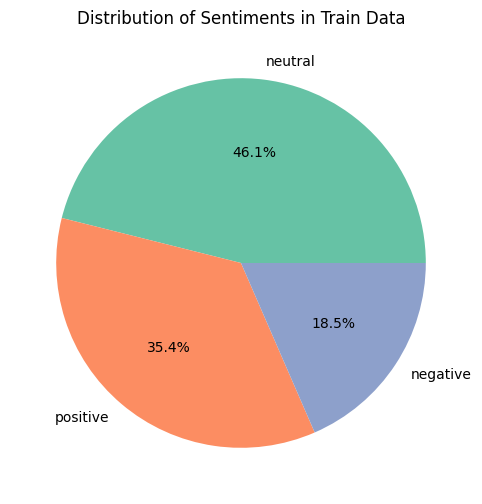

In [6]:
import matplotlib.pyplot as plt

# Counting the occurrences of each sentiment category
sentiment_counts = preprocessed_train_data['sentiment'].value_counts()
colors = ['#66c2a5', '#fc8d62', '#8da0cb']
# Plotting the counts in a pie chart
plt.figure(figsize=(8, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('Distribution of Sentiments in Train Data')
plt.show()

#### Feature Extraction

In [7]:
pip install gensim

In [8]:
# BOW
# Initializing the CountVectorizer
vectorizer = CountVectorizer()
# Fitting the vectorizer on the preprocessed training data and transforming the training data into BoW features
X_train_bow = vectorizer.fit_transform(preprocessed_train_data['processed_tweet_text'])
# Transforming the development data into BoW features using the same vectorizer
X_dev_bow = vectorizer.transform(preprocessed_dev_data['processed_tweet_text'])


X_test_bow = [vectorizer.transform(test_df['processed_tweet_text']) for test_df in preprocessed_test_data]
# Printing the shape of the transformed feature matrices
print("Training BoW Features Shape:", X_train_bow.shape)
print("Development BoW Features Shape:", X_dev_bow.shape)
for idx, X_test in enumerate(X_test_bow, start=1):
    print(f"Test Set {idx} BoW Features Shape:", X_test.shape)

# TFIDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
# Function to apply TF-IDF feature extraction to your datasets
def apply_tfidf_feature_extraction(preprocessed_train_data, preprocessed_dev_data, preprocessed_test_data):
    # Initializing the TF-IDF Vectorizer
    tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
    # Fitting the vectorizer on the preprocessed training data and transform the training data into TF-IDF features
    X_train_tfidf = tfidf_vectorizer.fit_transform(preprocessed_train_data['processed_tweet_text'])
    # Transforming the development data into TF-IDF features using the same vectorizer
    X_dev_tfidf = tfidf_vectorizer.transform(preprocessed_dev_data['processed_tweet_text'])

    X_test_tfidf = [tfidf_vectorizer.transform(test_df['processed_tweet_text']) for test_df in preprocessed_test_data]
    return X_train_tfidf, X_dev_tfidf, X_test_tfidf, tfidf_vectorizer
# Applying TF-IDF feature extraction to  preprocessed data
X_train_tfidf, X_dev_tfidf, X_test_tfidf, tfidf_vectorizer = apply_tfidf_feature_extraction(preprocessed_train_data, preprocessed_dev_data, preprocessed_test_data)
# Printing the shape of the transformed feature matrices
print("Training TF-IDF Features Shape:", X_train_tfidf.shape)
print("Development TF-IDF Features Shape:", X_dev_tfidf.shape)
for idx, X_test in enumerate(X_test_tfidf, start=1):
    print(f"Test Set {idx} TF-IDF Features Shape:", X_test.shape)

# GLOVE
import numpy as np
# GloVe embeddings loader
def load_glove_embeddings(path):
    embeddings_dict = {}
    with open(path, 'r', encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], "float32")
            embeddings_dict[word] = vector
    return embeddings_dict
# Tweets to GloVe embedding converter
def tweet_to_glove_embedding(tweet, embeddings_dict, embedding_dim=100):
    words = tweet.split()
    accumulated_vector = np.zeros(embedding_dim)
    word_count = 0
    for word in words:
        if word in embeddings_dict:
            word_vector = embeddings_dict[word]
            if len(word_vector) == embedding_dim:
                accumulated_vector += word_vector
                word_count += 1
    if word_count > 0:
        return accumulated_vector / word_count
    else:
        return np.zeros(embedding_dim)

glove_path = 'glove.6B.100d.txt'  # Update this path to the GloVe embeddings file
preprocessed_training_texts = preprocessed_train_data['processed_tweet_text']
preprocessed_dev_texts = preprocessed_dev_data['processed_tweet_text']
# Loading GloVe embeddings
glove_embeddings = load_glove_embeddings(glove_path)
# Converting tweets to GloVe embeddings for training and development data
glove_train = np.array([tweet_to_glove_embedding(tweet, glove_embeddings) for tweet in preprocessed_training_texts])
glove_dev = np.array([tweet_to_glove_embedding(tweet, glove_embeddings) for tweet in preprocessed_dev_texts])
glove_test = [np.array([tweet_to_glove_embedding(tweet, glove_embeddings) for tweet in test_df['processed_tweet_text']]) for test_df in preprocessed_test_data]

# WORD2VEC
from gensim.models import Word2Vec
import numpy as np
# Function to convert a tweet to its embedding by averaging the vectors of the words in the tweet
def tweet_to_word2vec_embedding(tweet, model):
    words = tweet.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)
# Train Word2Vec model and transform tweets into embeddings
def tweets_to_word2vec_embeddings(preprocessed_data, embedding_dim=500):
    # Tokenize tweets for Word2Vec
    tokenized_tweets = [tweet.split() for tweet in preprocessed_data['processed_tweet_text']]
    # Train Word2Vec model
    model = Word2Vec(sentences=tokenized_tweets, vector_size=embedding_dim, window=5, min_count=1, workers=4)
    # Convert tweets to embeddings using the trained model
    embeddings = np.array([tweet_to_word2vec_embedding(tweet, model) for tweet in preprocessed_data['processed_tweet_text']])
    return embeddings, model
# Apply the function to your datasets
X_train_word2vec, word2vec_model = tweets_to_word2vec_embeddings(preprocessed_train_data)
X_dev_word2vec = np.array([tweet_to_word2vec_embedding(tweet, word2vec_model) for tweet in preprocessed_dev_data['processed_tweet_text']])
X_test_word2vec = [np.array([tweet_to_word2vec_embedding(tweet, word2vec_model) for tweet in test_df['processed_tweet_text']]) for test_df in preprocessed_test_data]
# Example: Print the shape of the embeddings
print("Training Word2Vec Embeddings Shape:", X_train_word2vec.shape)
print("Development Word2Vec Embeddings Shape:", X_dev_word2vec.shape)
for idx, X_test in enumerate(X_test_word2vec, start=1):
    print(f"Test Set {idx} Word2Vec Embeddings Shape:", X_test.shape)

Training BoW Features Shape: (45026, 55935)
Development BoW Features Shape: (2000, 55935)
Test Set 1 BoW Features Shape: (3531, 55935)
Test Set 2 BoW Features Shape: (1853, 55935)
Test Set 3 BoW Features Shape: (2379, 55935)
Training TF-IDF Features Shape: (45026, 10000)
Development TF-IDF Features Shape: (2000, 10000)
Test Set 1 TF-IDF Features Shape: (3531, 10000)
Test Set 2 TF-IDF Features Shape: (1853, 10000)
Test Set 3 TF-IDF Features Shape: (2379, 10000)
Training Word2Vec Embeddings Shape: (45026, 500)
Development Word2Vec Embeddings Shape: (2000, 500)
Test Set 1 Word2Vec Embeddings Shape: (3531, 500)
Test Set 2 Word2Vec Embeddings Shape: (1853, 500)
Test Set 3 Word2Vec Embeddings Shape: (2379, 500)


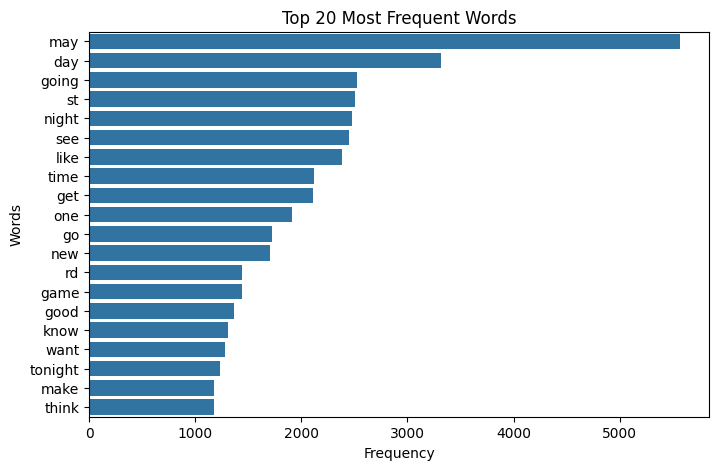

In [9]:
from collections import Counter
import seaborn as sns

# Count the frequency of words in the first test set for illustration
word_freq = Counter(" ".join(preprocessed_train_data['processed_tweet_text']).split())
most_common_words = word_freq.most_common(20)  # Top 20 words

# Extracting words and counts into separate lists for plotting
words, counts = zip(*most_common_words)

# Create a bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()


#### Build sentiment classifiers
You need to create your own classifiers (at least 3 classifiers). For each classifier, you can choose between the bag-of-word features and the word-embedding-based features. Each classifier has to be evaluated over 3 test sets. Make sure your classifier produce consistent performance across the test sets. Marking will be based on the performance over all 5 test sets (2 of them are not provided to you).

In [10]:
# LSTM
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import numpy as np



In [12]:
train_features = {'bow': X_train_bow, 'tfidf': X_train_tfidf, 'glove': glove_train, 'word2vec': X_train_word2vec}
test_features = {'bow': X_test_bow, 'tfidf': X_test_tfidf, 'glove': glove_test, 'word2vec': X_test_word2vec}
encoded_to_sentiment = {0: 'negative', 1: 'neutral', 2: 'positive'}
model = None
# Buid traditional sentiment classifiers. An example classifier name 'svm' is given
# in the code below. You should replace the other two classifier names
# with your own choices. For features used for classifier training,
# the 'bow' feature is given in the code. But you could also explore the
# use of other features.
for classifier in ['svm', 'logistic_regression', 'decision_tree', 'lstm']:
    for features in ['bow', 'tfidf', 'glove', 'word2vec']:
        # Skeleton: Creation and training of the classifiers
        if classifier == 'svm':
            print('Training ' + classifier + '-' + features + '123')
            if os.path.exists('' + classifier + '_' + features + '123' + '.pkl'):
                # Load the model from the pickle file
                with open('' + classifier + '_' + features + '123' + '.pkl', 'rb') as f:
                    model = pickle.load(f)
                print("Model loaded from pickle file.")
            else:
                from sklearn.svm import SVC
                from sklearn.metrics import classification_report
                # Initialize the SVM classifier
                svm_classifier = SVC(kernel='linear', random_state=42)
                # Train the SVM classifier
                model = svm_classifier.fit(train_features[features], preprocessed_train_data['sentiment'])
                # Saving model to pickle
                with open('' + classifier + '_' + features + '123' + '.pkl', 'wb') as f:
                    pickle.dump(model, f)
                print("Model trained and saved to pickle file.")
        elif classifier == 'logistic_regression':
            if os.path.exists('' + classifier + '_' + features + '123' + '.pkl'):
                # Load the model from the pickle file
                with open('' + classifier + '_' + features + '123' + '.pkl', 'rb') as f:
                    model = pickle.load(f)
                print("Model loaded from pickle file.")
            else:
                print('Training ' + classifier + '-' + features)
                logistic_classifier = LogisticRegression(max_iter=1000, random_state=42)
                # Train the Logistic Regression classifier
                # print(train_features[features])
                # print(preprocessed_train_data['sentiment'])
                model = logistic_classifier.fit(train_features[features], preprocessed_train_data['sentiment'])
                with open('' + classifier + '_' + features + '.pkl', 'wb') as f:
                    pickle.dump(model, f)
                print("Model trained and saved to pickle file.")
        elif classifier == 'decision_tree':
            if os.path.exists('' + classifier + '_' + features + '123' + '.pkl'):
                # Load the model from the pickle file
                with open('' + classifier + '_' + features + '123' + '.pkl', 'rb') as f:
                    model = pickle.load(f)
                print("Model loaded from pickle file.")
            else:
                print('Training ' + classifier + '-' + features)
                dt_classifier = DecisionTreeClassifier(random_state=42)
                # Train the Decision Tree classifier
                model = dt_classifier.fit(train_features[features], preprocessed_train_data['sentiment'])
                with open('' + classifier + '_' + features + '123' + '.pkl', 'wb') as f:
                    pickle.dump(model, f)
                print("Model trained and saved to pickle file.")
        elif classifier == 'lstm':
            # write the LSTM classifier here
            if features != 'glove':
                continue
            if os.path.exists('' + classifier + '_' + features + '123' + '.pkl'):
                # Load the model from the pickle file
                with open('' + classifier + '_' + features + '123' + '.pkl', 'rb') as f:
                    model = pickle.load(f)
                print("Model loaded from pickle file.")
            else:
                print('Training ' + classifier + '-' + features)
                # Define the LSTM model
                class LSTMClassifier(nn.Module):
                    def __init__(self, input_size, hidden_size, output_size):
                        super(LSTMClassifier, self).__init__()
                        self.hidden_size = hidden_size
                        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
                        self.fc = nn.Linear(hidden_size, output_size)
                        self.softmax = nn.LogSoftmax(dim=1)

                    def forward(self, input):

                        lstm_out, _ = self.lstm(input)
                        output = self.fc(lstm_out[:, -1, :])  # Get the last time step's output
                        output = self.softmax(output)
                        return output

                # Convert data to PyTorch tensors
                X_train_tensor = torch.tensor(glove_train, dtype=torch.float32)
                # Encode sentiment labels as integers
                label_encoder = LabelEncoder()
                y_train_encoded = label_encoder.fit_transform(preprocessed_train_data['sentiment'])
                # Convert labels to PyTorch tensors
                y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
                # Hyperparameters
                input_size = 100  # Dimension of GloVe embeddings
                hidden_size = 128
                output_size = len(label_encoder.classes_)  # Number of sentiment classes
                learning_rate = 0.001
                num_epochs = 10
                batch_size = 32
                # DataLoader for training and dev sets
                train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
                train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                # Initialize the LSTM classifier model
                model = LSTMClassifier(input_size, hidden_size, output_size)
                # Loss function and optimizer
                criterion = nn.CrossEntropyLoss()
                optimizer = optim.Adam(model.parameters(), lr=learning_rate)
                # Train the model
                model.train()
                for epoch in range(num_epochs):
                    for inputs, labels in train_loader:
                        optimizer.zero_grad()
                        # Add a sequence length dimension to inputs
                        inputs = inputs.unsqueeze(1)  # Reshape for LSTM [batch_size, 1, input_size]
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        loss.backward()
                        optimizer.step()
                    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}')
                with open('' + classifier + '_' + features + '.pkl', 'wb') as f:
                    pickle.dump(model, f)
                print("Model trained and saved to pickle file.")
        else:
            print('Unknown classifier name' + classifier)
            continue

        # Predition performance of the classifiers
        for index, testset in enumerate(testsets):
            if classifier != 'lstm':
                predictions = model.predict(test_features[features][index])
                # print(predictions)
            else:
                X_test_tensor = torch.tensor(test_features['glove'][index], dtype=torch.float32)
                y_test_encoded = label_encoder.transform(preprocessed_test_data[index]['sentiment'])
                y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)
                test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
                test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
                # Evaluate the model
                model.eval()
                y_true = []
                y_pred = []
                with torch.no_grad():
                    for inputs, labels in test_loader:
                        # Add a sequence length dimension to inputs
                        inputs = inputs.unsqueeze(1)  # Reshape for LSTM [batch_size, 1, input_size]
                        outputs = model(inputs)
                        _, predicted = torch.max(outputs, 1)
                        y_true.extend(labels.tolist())
                        y_pred.extend(predicted.tolist())
                predictions = y_pred
                predictions = list(map(encoded_to_sentiment.get, predictions))
                # print(np.unique(predictions))

            id_preds = {}
            with open(join('semeval-tweets', testset), 'r', encoding='utf8') as fh:
                for line in fh:
                    fields = line.split('\t')
                    tweetid = fields[0]
                    id_preds[tweetid] = None
            # Iterating through predictions to initialize the id_preds dictionary values
            for key, value in zip(id_preds.keys(), predictions):
                id_preds[key] = value
            evaluate(id_preds, join('semeval-tweets', testset), features + '-' + classifier)

Training svm-bow123
Model loaded from pickle file.
semeval-tweets/twitter-test1.txt (bow-svm): 0.535
semeval-tweets/twitter-test2.txt (bow-svm): 0.545
semeval-tweets/twitter-test3.txt (bow-svm): 0.523
Training svm-tfidf123
Model loaded from pickle file.
semeval-tweets/twitter-test1.txt (tfidf-svm): 0.551
semeval-tweets/twitter-test2.txt (tfidf-svm): 0.565
semeval-tweets/twitter-test3.txt (tfidf-svm): 0.517
Training svm-glove123
Model loaded from pickle file.
semeval-tweets/twitter-test1.txt (glove-svm): 0.411
semeval-tweets/twitter-test2.txt (glove-svm): 0.441
semeval-tweets/twitter-test3.txt (glove-svm): 0.420
Training svm-word2vec123
Model loaded from pickle file.
semeval-tweets/twitter-test1.txt (word2vec-svm): 0.217
semeval-tweets/twitter-test2.txt (word2vec-svm): 0.249
semeval-tweets/twitter-test3.txt (word2vec-svm): 0.206
Training logistic_regression-bow
Model trained and saved to pickle file.
semeval-tweets/twitter-test1.txt (bow-logistic_regression): 0.550
semeval-tweets/twitte